In [1]:
from scMM.file.data import CyESIData
data = CyESIData.load_from_file("/home/zby/scMM/data/P-1.mzML",
                                ref_mz = 760.5839, cell_snr = 5.0, peak_snr = 2.0)

In [2]:
data.save("/home/zby/scMM/data/QY")

In [10]:
from scMM.plot.engine import PlotEngine
eg = PlotEngine.from_adata(data.to_anndata(), fig_path_dir="/home/zby/scMM/data/QY/res")

/home/zby/miniconda3/envs/scMM/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/zby/miniconda3/envs/scMM/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [12]:
eg.pca(n_components=100)
eg.umap(use_pca=True, n_neighbors=20, min_dist=0.7)

/home/zby/miniconda3/envs/scMM/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


array([[ 1.81656208e+01,  8.07351494e+00],
       [ 1.82907467e+01,  3.84100795e+00],
       [ 2.00424919e+01,  7.39159489e+00],
       [ 1.88497639e+01,  8.17610931e+00],
       [ 1.89009094e+01,  7.12678480e+00],
       [ 1.62854729e+01,  7.95306635e+00],
       [ 2.04800339e+01,  2.29648972e+00],
       [ 1.62655029e+01,  7.79118252e+00],
       [ 1.69257431e+01,  7.21422815e+00],
       [ 1.45371799e+01,  6.94587469e-01],
       [ 1.93509846e+01,  7.78557205e+00],
       [ 1.94490929e+01,  3.55690455e+00],
       [ 1.95290947e+01,  7.00363874e+00],
       [ 1.84749947e+01,  9.36320877e+00],
       [ 2.07779007e+01,  5.57866192e+00],
       [ 2.07813969e+01,  6.04873514e+00],
       [ 1.98560448e+01,  8.33674526e+00],
       [ 1.75759048e+01,  7.53655195e+00],
       [ 1.73099918e+01,  8.50832176e+00],
       [ 2.09375458e+01,  1.05644627e+01],
       [ 1.72958298e+01,  7.33664370e+00],
       [ 2.20656796e+01,  1.04036722e+01],
       [ 1.65994720e+01,  7.12274122e+00],
       [ 1.

In [20]:
eg.cluster_cells(method="leiden", n_neighbors=20, resolution=0.225, key_added="leiden_cluster", s=20)

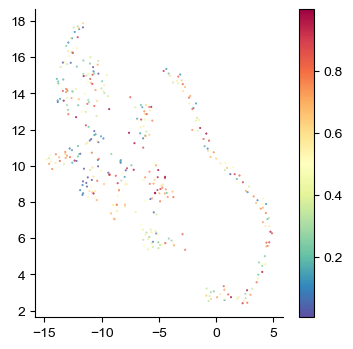

In [9]:
import matplotlib.pyplot as plt
X = eg.adata.obsm["X_umap"]
plt.scatter(X[:,0], X[:,1], c=data.peak_meta["time"], s=0.2)
plt.colorbar()
plt.show()

In [9]:
eg.compute_trajectory(step_size = 20, parameterization_key="time", plotting=True)

In [10]:
eg.plot_metabolite_trends(step_size=20, parameterization_key="time", plot_top_n=50, feature_name_key="mz")

In [11]:
eg.plot_trend_clusters()